# 06 - December guard variants

Backtest three proposed December-risk guards as temporary strategy variants built from the archived champion. This notebook does not edit the live strategy; it writes temporary `strategy.py` files, runs the canonical harness, and compares full-period/OOS/December behavior.

In [1]:
import json
import tempfile
from pathlib import Path
import sys; sys.path.insert(0, ".")
from _lab import *

best = json.loads(BEST_JSON.read_text(encoding="utf-8"))
symbols = list(best["symbols"])
params = dict(best["params"])
tf = best["tf"]
start, end = best["period"]
initial_cash = 1000.0
base_code = BEST_STRATEGY_FILE.read_text(encoding="utf-8")

print("baseline champion:", symbols, params)

baseline champion: ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'AVAXUSDT'] {'breakout_lookback': 8, 'volume_ma': 20, 'volume_mult': 1.9, 'flat_trend_span': 60, 'flat_slope_bars': 12, 'flat_slope_abs': 0.005, 'atr_period': 14, 'exhaustion_bars': 6, 'max_prior_move': 0.08, 'follow_volume_mult': 1.2, 'follow_bars': 3, 'take_atr': 2.5, 'max_hold_bars': 30}


In [2]:
def run_code_variant(name, code, params_override=None):
    tmp = tempfile.TemporaryDirectory(prefix=f"vwb_{name}_")
    path = Path(tmp.name)
    (path / "strategy.py").write_text(code, encoding="utf-8")
    p = dict(params)
    if params_override:
        p.update(params_override)
    res = run_strategy_file(path / "strategy.py", symbols, start, end, params=p, tf=tf, return_curves=True)
    res["_tmp"] = tmp
    res["_name"] = name
    return res

def result_summary(name, res):
    curves = res["curves"]
    eq = rebase(curves["equity"], initial_cash)
    dec_start = pd.Timestamp("2025-12-01", tz="UTC")
    dec_end = pd.Timestamp("2026-01-01", tz="UTC")
    eq_dec = eq[(eq.index >= dec_start) & (eq.index < dec_end)]
    trades = curves["trades"].copy()
    trades["entry_time"] = pd.to_datetime(trades["entry_time"], utc=True)
    dec = trades[(trades["entry_time"] >= dec_start) & (trades["entry_time"] < dec_end)]
    return {
        "variant": name,
        "end_equity": float(eq.iloc[-1]),
        "total_return": float(eq.iloc[-1] / eq.iloc[0] - 1),
        "max_dd": float(drawdown(eq).min()),
        "train_sharpe": res["main"]["train"].get("sharpe"),
        "oos_sharpe": res["main"]["oos"].get("sharpe"),
        "oos_return": res["main"]["oos"].get("total_return"),
        "oos_pf": res["main"]["oos"].get("profit_factor"),
        "n_trades": int(len(trades)),
        "dec_pnl": float(dec["pnl_quote"].sum()) if len(dec) else 0.0,
        "dec_trades": int(len(dec)),
        "dec_win_rate": float((dec["return_pct"] > 0).mean()) if len(dec) else np.nan,
        "dec_eq_return": float(eq_dec.iloc[-1] / eq_dec.iloc[0] - 1) if len(eq_dec) > 1 else np.nan,
        "dec_max_dd": float(drawdown(eq_dec).min()) if len(eq_dec) > 1 else np.nan,
    }

In [3]:
# Variant 1: volatility kill-switch for shorts.
vol_code = base_code.replace(
    "short_entry = cont_short | follow_short | failed_up",
    "short_entry = cont_short | follow_short | failed_up\n"
    "    short_vol_cap = float(params.get(\"short_vol_cap\", 0.70))\n"
    "    realized_vol_guard = close.pct_change().rolling(42, min_periods=42).std() * np.sqrt(6 * 365)\n"
    "    short_entry = short_entry & (realized_vol_guard <= short_vol_cap)"
)

# Variant 2: tighter, short-specific exhaustion guard: skip shorts after >5% 24h drop.
short_exhaust_code = base_code.replace(
    "not_down_exhausted = prior_move > -max_prior_move",
    "short_max_prior_move = float(params.get(\"short_max_prior_move\", 0.05))\n"
    "    not_down_exhausted = prior_move > -short_max_prior_move"
)

# Variant 3: market-wide short cluster guard. If >=2 symbols enter new shorts on
# the same bar and their mean 24h move is below -4.5%, remove those short legs
# until their next flat/long transition.
cluster_append = r'''

_base_generate_signals = generate_signals

def generate_signals(data: dict[str, pd.DataFrame], params: dict) -> pd.DataFrame:
    signals = _base_generate_signals(data, params)
    if signals.empty:
        return signals
    min_cluster = int(params.get("short_cluster_min", 2))
    prior_threshold = float(params.get("short_cluster_prior_move", -0.045))
    s = signals.copy()
    s["timestamp"] = pd.to_datetime(s["timestamp"], utc=True)
    wide = s.pivot_table(index="timestamp", columns="symbol", values="position", aggfunc="last").sort_index().ffill().fillna(0.0)
    prior = {}
    for sym, df in data.items():
        prior[sym] = df["close"].astype(float).pct_change(6).reindex(wide.index)
    prior = pd.DataFrame(prior).reindex(columns=wide.columns)
    prev = wide.shift(1).fillna(0.0)
    short_entries = (wide < 0) & (prev >= 0)
    for ts in wide.index[short_entries.sum(axis=1) >= min_cluster]:
        syms = list(short_entries.columns[short_entries.loc[ts]])
        if len(syms) < min_cluster:
            continue
        mean_prior = float(prior.loc[ts, syms].mean())
        if not np.isfinite(mean_prior) or mean_prior > prior_threshold:
            continue
        for sym in syms:
            idx = wide.index.get_loc(ts)
            j = idx
            while j < len(wide.index) and wide.iat[j, wide.columns.get_loc(sym)] < 0:
                wide.iat[j, wide.columns.get_loc(sym)] = 0.0
                j += 1
    out = wide.reset_index().melt(id_vars="timestamp", var_name="symbol", value_name="position")
    return out
'''
cluster_code = base_code + cluster_append

variants = {
    "champion": (base_code, {}),
    "short_vol_cap_0.70": (vol_code, {"short_vol_cap": 0.70}),
    "short_exhaust_5pct": (short_exhaust_code, {"short_max_prior_move": 0.05}),
    "short_cluster_guard": (cluster_code, {"short_cluster_min": 2, "short_cluster_prior_move": -0.045}),
}

results = {}
for name, (code, pover) in variants.items():
    print("running", name)
    results[name] = run_code_variant(name, code, pover)
print("done")

running champion


running short_vol_cap_0.70


running short_exhaust_5pct


running short_cluster_guard


done


In [4]:
summary = pd.DataFrame([result_summary(name, res) for name, res in results.items()]).set_index("variant")
summary

,end_equity,total_return,max_dd,train_sharpe,oos_sharpe,oos_return,oos_pf,n_trades,dec_pnl,dec_trades,dec_win_rate,dec_eq_return,dec_max_dd
variant,,,,,,,,,,,,,
champion,2039.424881,1.039425,-0.114798,2.256844,0.376976,0.032848,1.054225,516,-1824.621128,25,0.320000,-0.082548,-0.100312
short_vol_cap_0.70,1628.701247,0.628701,-0.102692,1.477033,1.472441,0.143927,1.337645,439,-1129.554961,17,0.235294,-0.065232,-0.077644
short_exhaust_5pct,1629.814441,0.629814,-0.104318,1.577059,0.972843,0.109565,1.211453,436,-411.650468,22,0.363636,-0.025072,-0.068089
short_cluster_guard,1888.869447,0.888869,-0.087204,2.123480,0.636343,0.051680,1.115047,454,-511.676517,22,0.363636,-0.026796,-0.067896


[saved] notebooks\volume_weighted_breakout\_out\06_december_guards_full_equity_drawdown.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/06_december_guards_full_equity_drawdown.png')

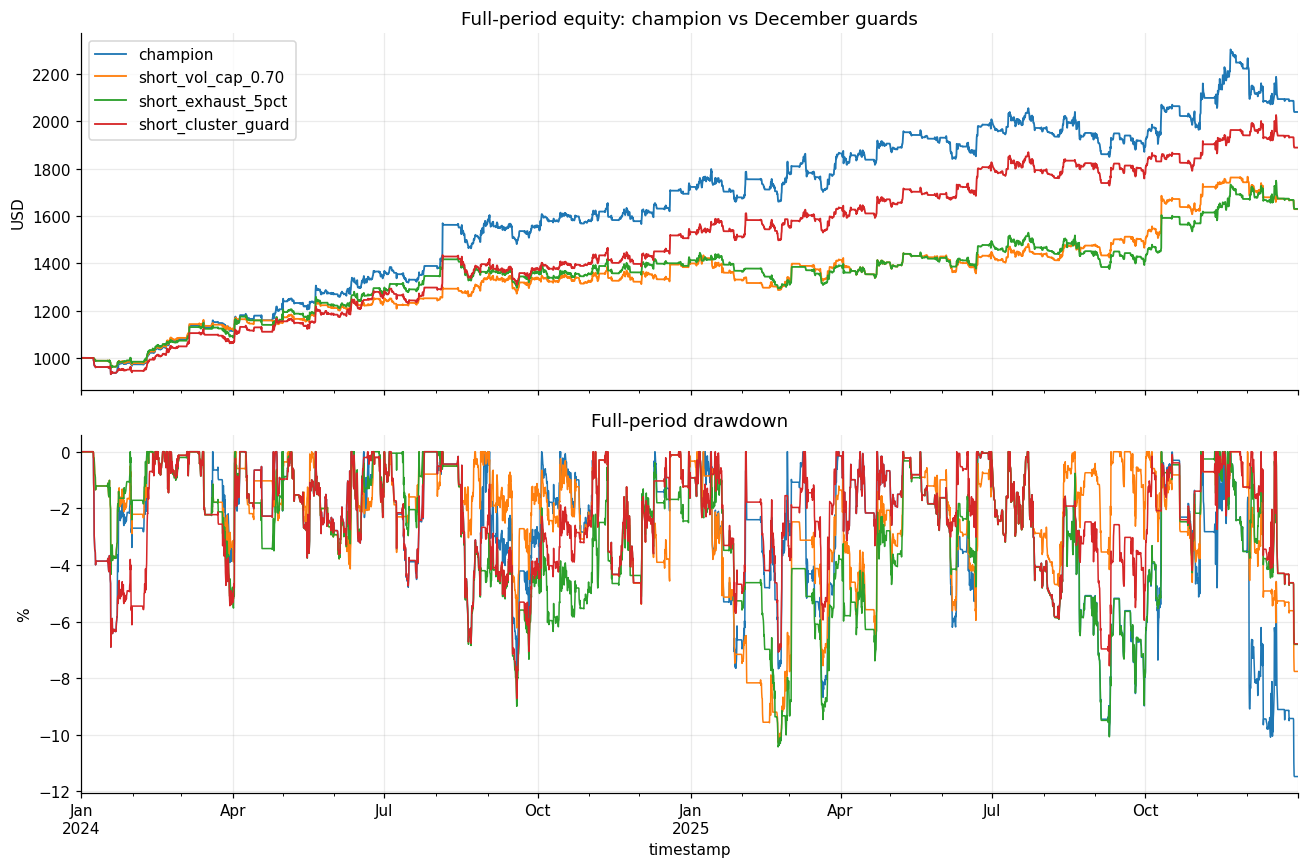

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for name, res in results.items():
    eq = rebase(res["curves"]["equity"], initial_cash)
    eq.plot(ax=ax[0], label=name, lw=1.2)
    (drawdown(eq) * 100).plot(ax=ax[1], label=name, lw=1.0)
ax[0].set_title("Full-period equity: champion vs December guards")
ax[0].set_ylabel("USD")
ax[0].legend(loc="best")
ax[1].set_title("Full-period drawdown")
ax[1].set_ylabel("%")
show("06_december_guards_full_equity_drawdown")

[saved] notebooks\volume_weighted_breakout\_out\06_december_guards_december_equity_drawdown.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/06_december_guards_december_equity_drawdown.png')

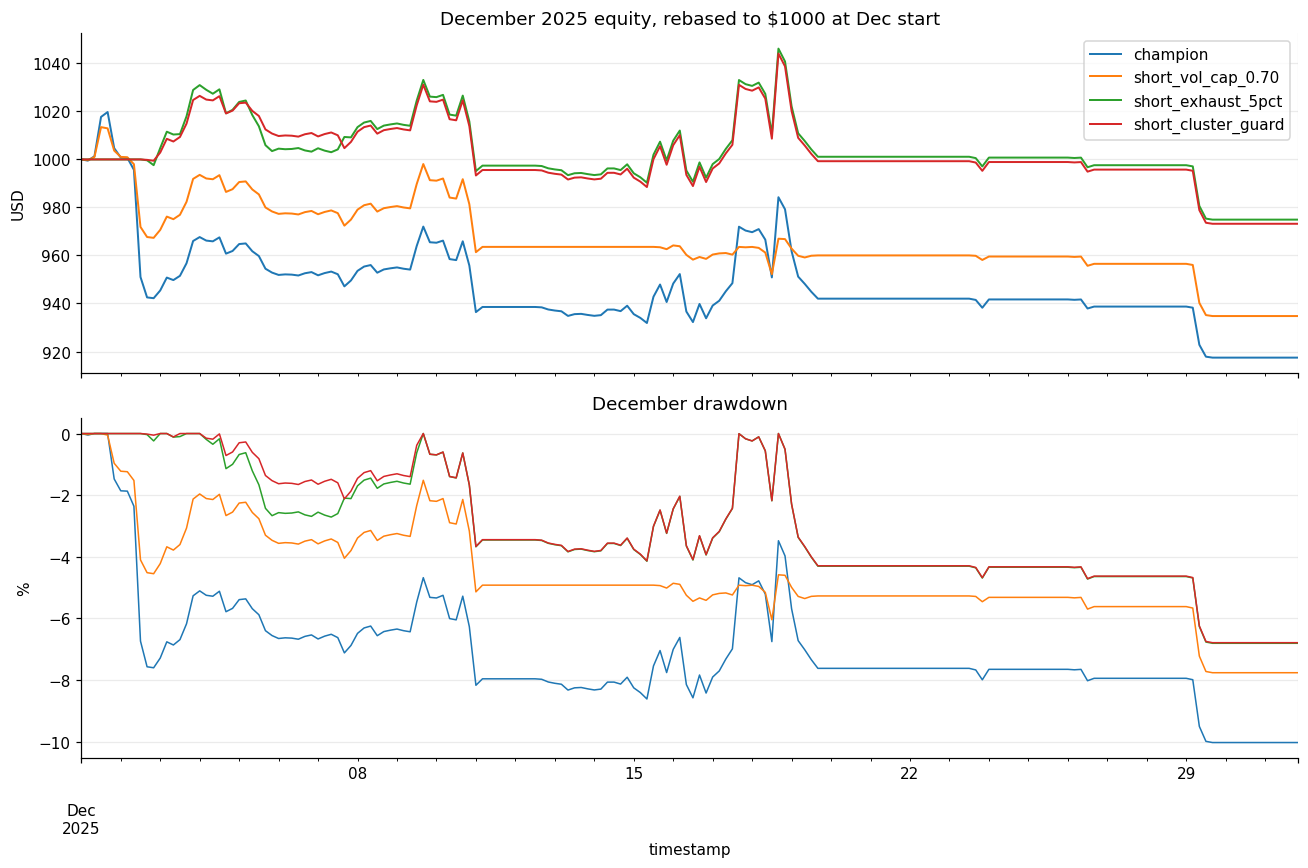

In [6]:
dec_start = pd.Timestamp("2025-12-01", tz="UTC")
dec_end = pd.Timestamp("2026-01-01", tz="UTC")
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for name, res in results.items():
    eq = rebase(res["curves"]["equity"], initial_cash)
    eq_dec = eq[(eq.index >= dec_start) & (eq.index < dec_end)]
    (eq_dec / eq_dec.iloc[0] * 1000).plot(ax=ax[0], label=name, lw=1.3)
    (drawdown(eq_dec) * 100).plot(ax=ax[1], label=name, lw=1.0)
ax[0].set_title("December 2025 equity, rebased to $1000 at Dec start")
ax[0].set_ylabel("USD")
ax[0].legend(loc="best")
ax[1].set_title("December drawdown")
ax[1].set_ylabel("%")
show("06_december_guards_december_equity_drawdown")

,end_equity,max_dd,oos_sharpe,oos_return,oos_pf,dec_pnl,dec_eq_return,dec_max_dd,n_trades
variant,,,,,,,,,
champion,2039.424881,-0.114798,0.376976,0.032848,1.054225,-1824.621128,-0.082548,-0.100312,516
short_vol_cap_0.70,1628.701247,-0.102692,1.472441,0.143927,1.337645,-1129.554961,-0.065232,-0.077644,439
short_exhaust_5pct,1629.814441,-0.104318,0.972843,0.109565,1.211453,-411.650468,-0.025072,-0.068089,436
short_cluster_guard,1888.869447,-0.087204,0.636343,0.051680,1.115047,-511.676517,-0.026796,-0.067896,454


[saved] notebooks\volume_weighted_breakout\_out\06_december_guards_metric_bars.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/06_december_guards_metric_bars.png')

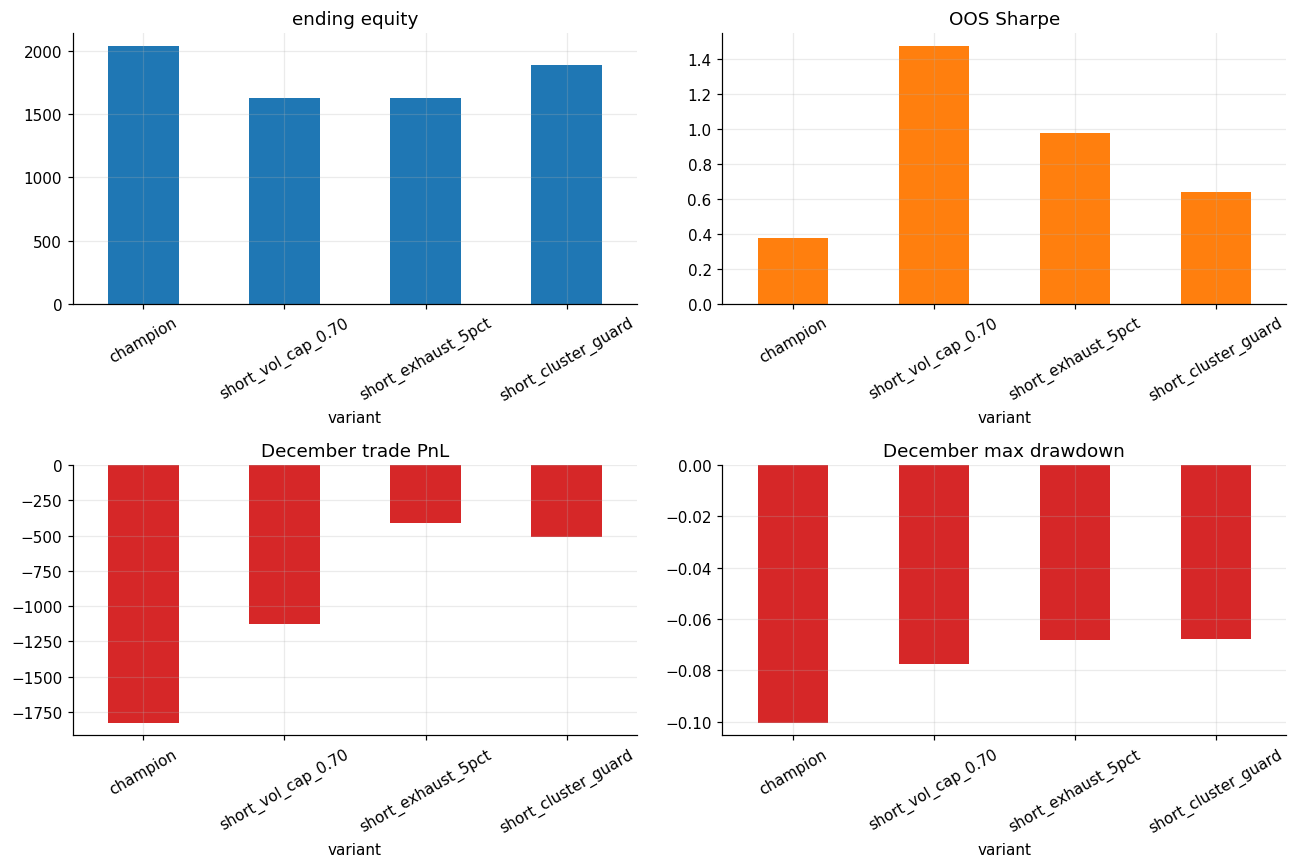

In [7]:
plot_cols = ["end_equity", "max_dd", "oos_sharpe", "oos_return", "oos_pf", "dec_pnl", "dec_eq_return", "dec_max_dd", "n_trades"]
display(summary[plot_cols])

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
summary["end_equity"].plot(kind="bar", ax=ax[0,0], color="C0")
ax[0,0].set_title("ending equity")
summary["oos_sharpe"].plot(kind="bar", ax=ax[0,1], color="C1")
ax[0,1].set_title("OOS Sharpe")
summary["dec_pnl"].plot(kind="bar", ax=ax[1,0], color=np.where(summary["dec_pnl"] >= 0, "C2", "C3"))
ax[1,0].set_title("December trade PnL")
summary["dec_max_dd"].plot(kind="bar", ax=ax[1,1], color="C3")
ax[1,1].set_title("December max drawdown")
for axis in ax.ravel():
    axis.tick_params(axis="x", rotation=30)
show("06_december_guards_metric_bars")

,champion,short_vol_cap_0.70,short_exhaust_5pct,short_cluster_guard
entry_day,,,,
2025-12-01 00:00:00+00:00,-1272.331597,-560.069786,0.000000,0.000000
2025-12-02 00:00:00+00:00,422.461198,341.252225,310.978512,391.401205
2025-12-03 00:00:00+00:00,-189.894584,-153.391031,-151.398143,-175.931716
2025-12-05 00:00:00+00:00,-72.476999,-58.544700,0.000000,-67.147796
2025-12-07 00:00:00+00:00,435.578645,351.847093,349.257632,403.550732
2025-12-09 00:00:00+00:00,-681.011502,-550.100241,-546.068191,-630.937015
2025-12-12 00:00:00+00:00,431.870039,0.000000,346.294431,400.114818
2025-12-15 00:00:00+00:00,408.326882,-0.836382,327.416382,378.302780
2025-12-17 00:00:00+00:00,74.098628,59.886569,59.415889,68.650187


[saved] notebooks\volume_weighted_breakout\_out\06_december_guards_daily_pnl.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/06_december_guards_daily_pnl.png')

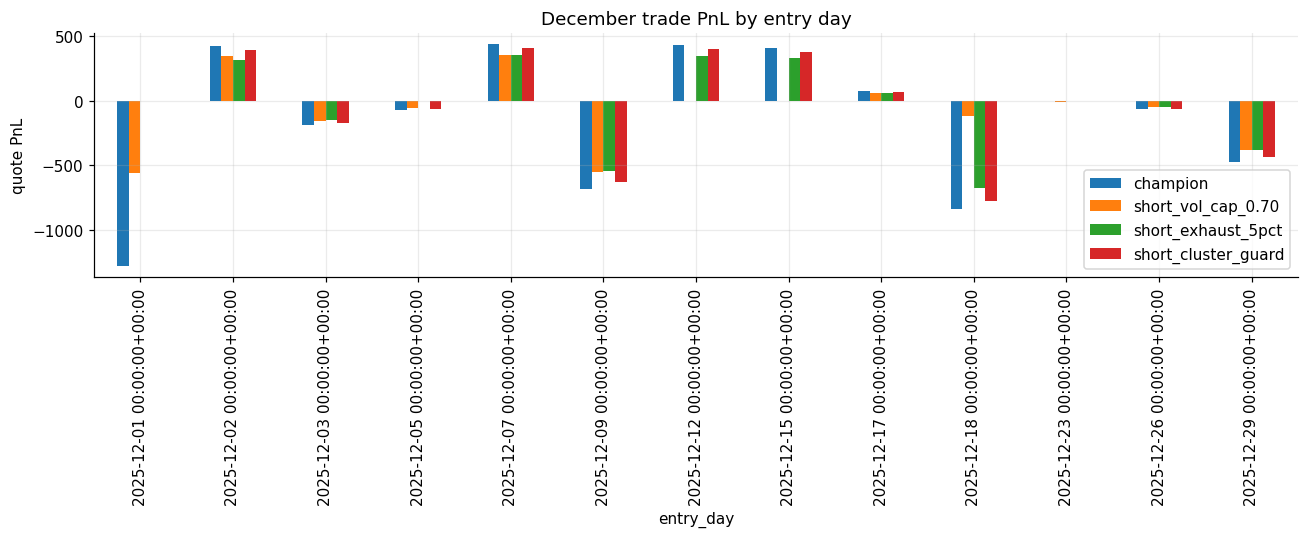

In [8]:
# December day-level PnL comparison from each variant's trade ledger.
daily_frames = []
for name, res in results.items():
    tr = res["curves"]["trades"].copy()
    tr["entry_time"] = pd.to_datetime(tr["entry_time"], utc=True)
    dec = tr[(tr["entry_time"] >= dec_start) & (tr["entry_time"] < dec_end)].copy()
    dec["entry_day"] = dec["entry_time"].dt.floor("D")
    d = dec.groupby("entry_day")["pnl_quote"].sum().rename(name)
    daily_frames.append(d)
daily_cmp = pd.concat(daily_frames, axis=1).fillna(0.0)
display(daily_cmp)
daily_cmp.plot(kind="bar", figsize=(12, 5))
plt.title("December trade PnL by entry day")
plt.ylabel("quote PnL")
show("06_december_guards_daily_pnl")

In [9]:
# Which trades were removed/changed in December?
for name, res in results.items():
    tr = res["curves"]["trades"].copy()
    tr["entry_time"] = pd.to_datetime(tr["entry_time"], utc=True)
    dec = tr[(tr["entry_time"] >= dec_start) & (tr["entry_time"] < dec_end)].copy()
    print("\n", name, "dec trades", len(dec), "pnl", dec["pnl_quote"].sum())
    display(dec[["entry_time", "exit_time", "symbol", "direction", "pnl_quote", "return_pct", "duration_hours"]].sort_values("entry_time"))


 champion dec trades 25 pnl -1824.6211283216348


,entry_time,exit_time,symbol,direction,pnl_quote,return_pct,duration_hours
169,2025-12-01 04:00:00+00:00,2025-12-02 16:00:00+00:00,BTCUSDT,Short,-349.375703,-0.059998,36.0
311,2025-12-01 04:00:00+00:00,2025-12-02 16:00:00+00:00,ETHUSDT,Short,-360.767794,-0.061037,36.0
420,2025-12-01 04:00:00+00:00,2025-12-02 16:00:00+00:00,SOLUSDT,Short,-562.188100,-0.095750,36.0
511,2025-12-02 16:00:00+00:00,2025-12-03 20:00:00+00:00,AVAXUSDT,Long,422.461198,0.079581,28.0
312,2025-12-03 16:00:00+00:00,2025-12-05 20:00:00+00:00,ETHUSDT,Long,-189.894584,-0.033407,52.0
170,2025-12-05 20:00:00+00:00,2025-12-07 20:00:00+00:00,BTCUSDT,Short,-72.476999,-0.013338,48.0
313,2025-12-07 20:00:00+00:00,2025-12-09 20:00:00+00:00,ETHUSDT,Long,435.578645,0.080723,48.0
171,2025-12-09 16:00:00+00:00,2025-12-11 04:00:00+00:00,BTCUSDT,Long,-212.428241,-0.038519,36.0
512,2025-12-09 16:00:00+00:00,2025-12-11 04:00:00+00:00,AVAXUSDT,Long,-471.754097,-0.080455,36.0
421,2025-12-09 20:00:00+00:00,2025-12-10 00:00:00+00:00,SOLUSDT,Long,3.170837,0.000585,4.0



 short_vol_cap_0.70 dec trades 17 pnl -1129.5549606142665


,entry_time,exit_time,symbol,direction,pnl_quote,return_pct,duration_hours
166,2025-12-01 04:00:00+00:00,2025-12-02 16:00:00+00:00,BTCUSDT,Short,-275.844004,-0.060450,36.0
299,2025-12-01 04:00:00+00:00,2025-12-02 16:00:00+00:00,ETHUSDT,Short,-284.225783,-0.061508,36.0
437,2025-12-02 16:00:00+00:00,2025-12-03 20:00:00+00:00,AVAXUSDT,Long,341.252225,0.079582,28.0
300,2025-12-03 16:00:00+00:00,2025-12-05 20:00:00+00:00,ETHUSDT,Long,-153.391031,-0.033407,52.0
167,2025-12-05 20:00:00+00:00,2025-12-07 20:00:00+00:00,BTCUSDT,Short,-58.544700,-0.013338,48.0
301,2025-12-07 20:00:00+00:00,2025-12-09 20:00:00+00:00,ETHUSDT,Long,351.847093,0.080723,48.0
168,2025-12-09 16:00:00+00:00,2025-12-11 04:00:00+00:00,BTCUSDT,Long,-171.593029,-0.038519,36.0
438,2025-12-09 16:00:00+00:00,2025-12-11 04:00:00+00:00,AVAXUSDT,Long,-381.068516,-0.080455,36.0
380,2025-12-09 20:00:00+00:00,2025-12-10 00:00:00+00:00,SOLUSDT,Long,2.561305,0.000585,4.0
169,2025-12-15 16:00:00+00:00,2025-12-17 16:00:00+00:00,BTCUSDT,Short,-0.836382,-0.000192,48.0



 short_exhaust_5pct dec trades 22 pnl -411.6504680932392


,entry_time,exit_time,symbol,direction,pnl_quote,return_pct,duration_hours
151,2025-12-02 16:00:00+00:00,2025-12-07 16:00:00+00:00,BTCUSDT,Long,-27.626974,-0.006204,120.0
431,2025-12-02 16:00:00+00:00,2025-12-03 20:00:00+00:00,AVAXUSDT,Long,338.605486,0.079768,28.0
276,2025-12-03 16:00:00+00:00,2025-12-05 20:00:00+00:00,ETHUSDT,Long,-151.398143,-0.033541,52.0
277,2025-12-07 20:00:00+00:00,2025-12-09 20:00:00+00:00,ETHUSDT,Long,349.257632,0.080733,48.0
152,2025-12-09 16:00:00+00:00,2025-12-11 04:00:00+00:00,BTCUSDT,Long,-170.335310,-0.038519,36.0
432,2025-12-09 16:00:00+00:00,2025-12-11 04:00:00+00:00,AVAXUSDT,Long,-378.275412,-0.080455,36.0
362,2025-12-09 20:00:00+00:00,2025-12-10 00:00:00+00:00,SOLUSDT,Long,2.542531,0.000585,4.0
278,2025-12-12 16:00:00+00:00,2025-12-17 16:00:00+00:00,ETHUSDT,Short,346.294431,0.068784,120.0
153,2025-12-15 16:00:00+00:00,2025-12-17 16:00:00+00:00,BTCUSDT,Short,-1.431672,-0.000319,48.0
433,2025-12-15 16:00:00+00:00,2025-12-17 20:00:00+00:00,AVAXUSDT,Short,177.442963,0.037276,52.0



 short_cluster_guard dec trades 22 pnl -511.6765165292107


,entry_time,exit_time,symbol,direction,pnl_quote,return_pct,duration_hours
449,2025-12-02 16:00:00+00:00,2025-12-03 20:00:00+00:00,AVAXUSDT,Long,391.401205,0.079582,28.0
281,2025-12-03 16:00:00+00:00,2025-12-05 20:00:00+00:00,ETHUSDT,Long,-175.931716,-0.033407,52.0
154,2025-12-05 20:00:00+00:00,2025-12-07 20:00:00+00:00,BTCUSDT,Short,-67.147796,-0.013338,48.0
282,2025-12-07 20:00:00+00:00,2025-12-09 20:00:00+00:00,ETHUSDT,Long,403.550732,0.080723,48.0
155,2025-12-09 16:00:00+00:00,2025-12-11 04:00:00+00:00,BTCUSDT,Long,-196.808483,-0.038519,36.0
450,2025-12-09 16:00:00+00:00,2025-12-11 04:00:00+00:00,AVAXUSDT,Long,-437.066219,-0.080455,36.0
373,2025-12-09 20:00:00+00:00,2025-12-10 00:00:00+00:00,SOLUSDT,Long,2.937686,0.000585,4.0
283,2025-12-12 16:00:00+00:00,2025-12-17 16:00:00+00:00,ETHUSDT,Short,400.114818,0.068784,120.0
156,2025-12-15 16:00:00+00:00,2025-12-17 16:00:00+00:00,BTCUSDT,Short,-1.654179,-0.000319,48.0
451,2025-12-15 16:00:00+00:00,2025-12-17 20:00:00+00:00,AVAXUSDT,Short,205.020793,0.037276,52.0
